# Week11: A Guide to Fuzzy Logic with Scikit-Fuzzy - Part 2 : Fuzzy Logic Clustering

This notebook serves as part of the **Computer Intelligence and its Applications in Mechatronics** course at **Amirkabir University of Technology**. It introduces the concept of fuzzy clustering, a powerful technique that allows data points to belong to multiple clusters with varying degrees of membership. We will primarily focus on the **Fuzzy C-Means (FCM)** algorithm and its implementation using the `scikit-fuzzy` (skfuzzy) Python library.

In This notebook, we will cover the following topics:
-  Introduction to Fuzzy Clustering and its difference from hard clustering.
-  The Fuzzy C-Means (FCM) algorithm: overview, parameters.
-  Implementing FCM with `skfuzzy.cluster.cmeans`.
-  Preparing data and understanding inputs/outputs of FCM.
-  Visualizing fuzzy clustering results: data points, cluster centers, and memberships.
-  Predicting cluster memberships for new data using `skfuzzy.cluster.cmeans_predict`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

## What is Fuzzy Clustering?

In traditional **hard clustering** (like K-Means), each data point is assigned to exactly one cluster. However, in many real-world scenarios, boundaries between clusters are not always sharply defined. Data points might share characteristics of multiple clusters, or lie in overlapping regions.

**Fuzzy clustering** addresses this by allowing data points to belong to multiple clusters simultaneously, with a **degree of membership** for each. This membership degree is a value between 0 and 1, where 0 means the point does not belong to the cluster at all, 1 means it fully belongs, and values in between indicate partial membership.

The sum of membership degrees for a single data point across all clusters must equal 1.

**Advantages of Fuzzy Clustering:**
* More natural representation for data with ambiguous boundaries.
* Provides richer information about the data structure.
* Can be more robust to outliers and noise in some cases.

The most widely used fuzzy clustering algorithm is **Fuzzy C-Means (FCM)**.

## The Fuzzy C-Means (FCM) Algorithm

FCM is a partitional clustering algorithm similar to K-Means, but it employs the concept of fuzzy memberships.

**Objective:** FCM aims to minimize an objective function that considers both the distance of data points to cluster centers and the fuzziness of the resulting clusters:
$$ J_m = \sum_{i=1}^{N} \sum_{j=1}^{C} u_{ij}^m ||x_i - c_j||^2 $$
Where:
* `N` is the number of data points.
* `C` is the number of clusters.
* `x_i` is the i-th data point.
* `c_j` is the center of the j-th cluster.
* `u_ij` is the degree of membership of data point `x_i` in cluster `j`.
* `m` is the **fuzziness coefficient** (or fuzzifier), a real number greater than 1. It controls the extent of fuzziness in the clustering. As `m` approaches 1, FCM behaves more like K-Means (hard clustering). As `m` increases, the clusters become fuzzier.

**Iterative Process:**
1.  Initialize cluster centers (randomly or using some heuristic).
2.  **Update Memberships:** Calculate the membership `u_ij` of each data point `x_i` to each cluster `c_j` based on the current cluster centers.
3.  **Update Cluster Centers:** Recalculate the cluster centers `c_j` based on the current memberships.
4.  Repeat steps 2 and 3 until the objective function `J_m` converges (changes by less than a specified tolerance) or a maximum number of iterations is reached.

## 1. Generating Sample Data

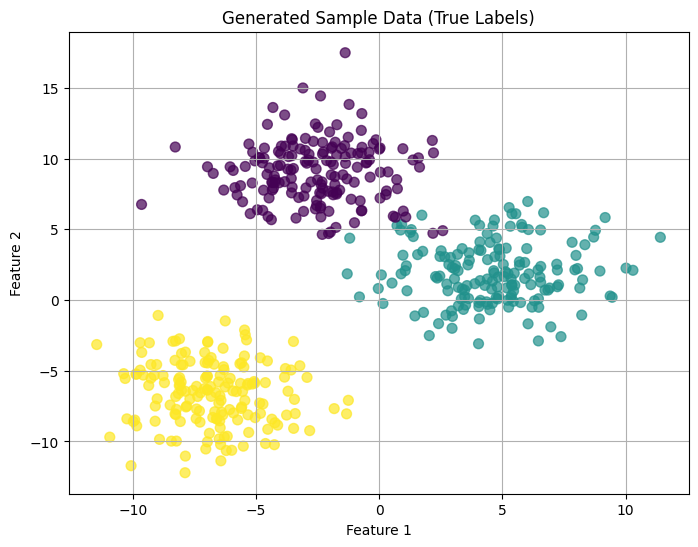

In [6]:
# Generate synthetic data with make_blobs
n_samples = 500
n_clusters_true = 3 # True number of clusters for generation
random_state = 42

data, true_labels = make_blobs(n_samples=n_samples, 
                               centers=n_clusters_true, 
                               cluster_std=2.2,
                               random_state=random_state)

data = data.T

# Plot the original data
plt.figure(figsize=(8, 6))
plt.scatter(data[0, :], data[1, :], c=true_labels, s=50, cmap='viridis', alpha=0.7)
plt.title('Generated Sample Data (True Labels)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

## 2. Implementing FCM with `skfuzzy.cluster.cmeans`

The `scikit-fuzzy` library provides the `cmeans` function for performing Fuzzy C-Means clustering.

**Key Parameters for `fuzz.cluster.cmeans`:**
* `data`: The dataset. **Important:** `scikit-fuzzy` expects data points to be in columns, and features in rows. So, if your data `X` has `N` samples and `D` features (shape `(N, D)`), you need to pass `X.T` (shape `(D, N)`).
* `c`: The desired number of clusters.
* `m`: The fuzziness coefficient (array exponent, `m > 1`).
* `error`: Tolerance for the objective function to stop iterations (e.g., `0.005`).
* `maxiter`: Maximum number of iterations (e.g., `1000`).
* `init`: Initialization method for cluster centers. Can be `None` (random initialization), or an initial guess for the membership matrix `u`.
* `seed`: For reproducible random initialization.

**Outputs of `fuzz.cluster.cmeans`:**
* `cntr`: The final cluster centers (centroids). Shape is `(c, D)` if input data was `(D,N)`.
* `u`: The final fuzzy membership matrix. Shape is `(c, N)`. `u[i, j]` is the membership of data point `j` in cluster `i`.
* `u0`: Initial fuzzy membership matrix.
* `d`: Euclidean distance from each point to each cluster center.
* `jm`: History of the objective function `J_m` values during iterations.
* `p`: Number of iterations run.
* `fpc`: Fuzzy Partition Coefficient (a measure of cluster validity/separation, higher is better, ranges from `1/c` to `1`).

In [7]:
# Set FCM parameters
n_clusters_fcm = 3          # Number of clusters we want to find
m_fuzziness = 2.0           # Fuzziness coefficient (standard value)
error_tolerance = 0.005
max_iterations = 1000
fcm_seed = 42               # For reproducibility

# Run FCM
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data, 
    c=n_clusters_fcm, 
    m=m_fuzziness, 
    error=error_tolerance, 
    maxiter=max_iterations,
    init=None, # Uses random initialization
    seed=fcm_seed
)

# `cntr` has cluster centers. Its shape will be (n_clusters_fcm, n_features)
# `u` has membership values. Its shape will be (n_clusters_fcm, n_samples)
print(f"Cluster centers shape: {cntr.shape}")
print(f"Membership matrix u shape: {u.shape}")
print(f"Fuzzy Partition Coefficient (FPC): {fpc:.4f}")
print(f"Iterations run: {p}")

Cluster centers shape: (3, 2)
Membership matrix u shape: (3, 500)
Fuzzy Partition Coefficient (FPC): 0.8345
Iterations run: 12


### 2.1. Understanding the Membership Matrix `u`

The matrix `u` contains the core result of fuzzy clustering. `u[i, j]` represents the membership of data point `j` in cluster `i`.
For each data point (column `j` in `u`), the sum of its memberships across all clusters (rows in `u`) should be 1.

In [9]:
# Display memberships for the first few data points
print("Memberships for the first 5 data points (columns are points, rows are clusters):")
print(u[:, :5])

# Verify that memberships sum to 1 for each data point
sum_of_memberships = np.sum(u, axis=0) # Sum along columns (for each point)
print("\nSum of memberships for the first 5 data points (should be close to 1):")
print(sum_of_memberships[:5])

Memberships for the first 5 data points (columns are points, rows are clusters):
[[0.0273448  0.32955957 0.09453578 0.82622113 0.04178462]
 [0.04555672 0.49695582 0.83738454 0.11687913 0.93205286]
 [0.92709848 0.1734846  0.06807968 0.05689974 0.02616252]]

Sum of memberships for the first 5 data points (should be close to 1):
[1. 1. 1. 1. 1.]


## 3. Visualizing Fuzzy Clustering Results

### 3.1. Plotting Data with Cluster Assignment (Max Membership)

For a simple visualization, we can assign each data point to the cluster for which it has the highest membership. This gives a "crisp" representation of the fuzzy result.

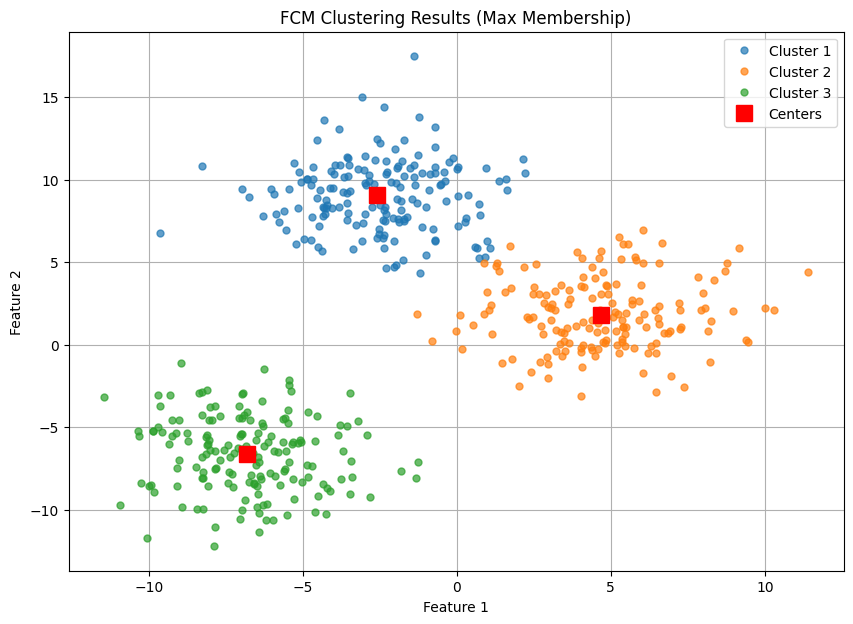

In [11]:
# Get the cluster labels by finding the cluster with max membership for each point
cluster_membership = np.argmax(u, axis=0) # u has shape (n_clusters, n_samples)

# Plot the data with FCM assignments and cluster centers
plt.figure(figsize=(10, 7))

# Plot data points
for j in range(n_clusters_fcm):
    plt.plot(data[0, cluster_membership == j],
             data[1, cluster_membership == j], '.', 
             label=f'Cluster {j+1}', markersize=10, alpha=0.7)

# Plot cluster centers
for pt in cntr:
    plt.plot(pt[0], pt[1], 'rs', markersize=12, label='Centers' if 'Centers' not in plt.gca().get_legend_handles_labels()[1] else "")

plt.title('FCM Clustering Results (Max Membership)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

### 3.2. Visualizing Membership Degrees for a Specific Cluster

We can also visualize the strength of membership for each point to a *specific* cluster. For example, by using the membership degree to control the color intensity or size of the points.

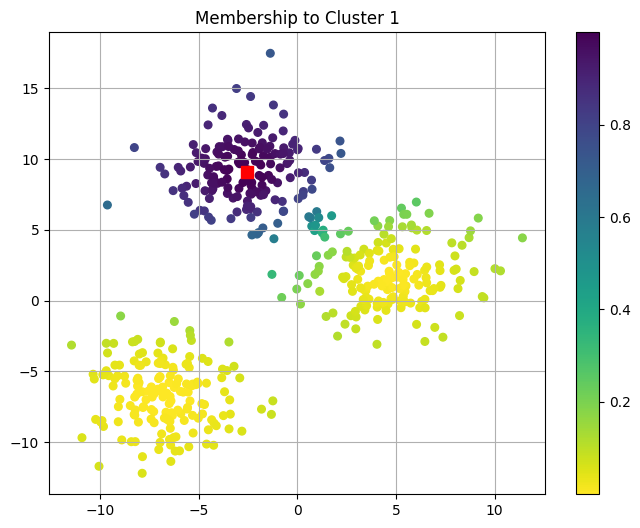

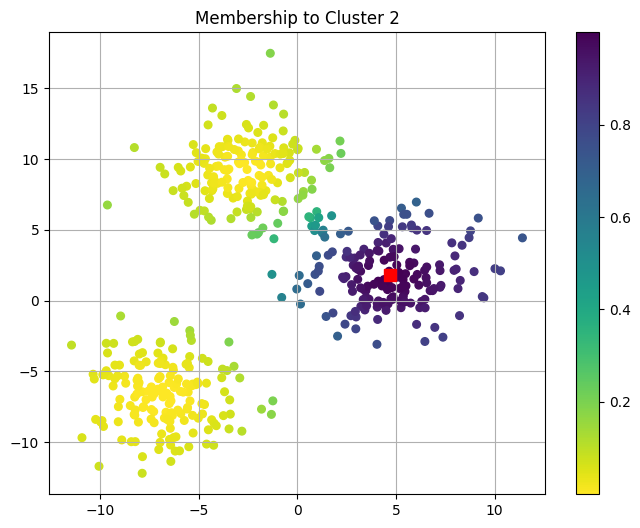

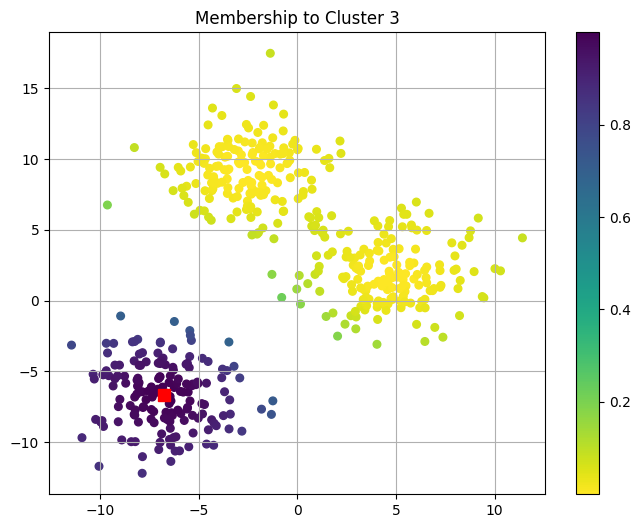

In [16]:
for i in range(n_clusters_fcm):
     plt.figure(figsize=(8,6))
     plt.scatter(data[0, :], data[1, :], c=u[i, :], s=30, cmap='viridis_r')
     plt.plot(cntr[i,0], cntr[i,1], 'rs', markersize=8)
     plt.title(f'Membership to Cluster {i+1}')
     plt.colorbar()
     plt.grid(True)
     plt.show()

Points with higher color intensity (or larger size, depending on visualization choice) have a stronger membership to the selected cluster. Notice how points in overlapping regions might show moderate membership to multiple clusters if you were to plot them side-by-side.

## 4. Impact of FCM Parameters


### 4.1. Number of Clusters (`c`)

Choosing the correct number of clusters (`c`) is crucial and often domain-dependent. If `c` is too small, distinct groups might be merged. If `c` is too large, single groups might be split.

The Fuzzy Partition Coefficient (FPC) output by `cmeans` can be one indicator. Values closer to 1 suggest better-defined clusters. You can try running FCM with different `c` values and observe FPC and the visual results.

Let's try with `c=2` and `c=4` for our data which was generated with 3 clusters.

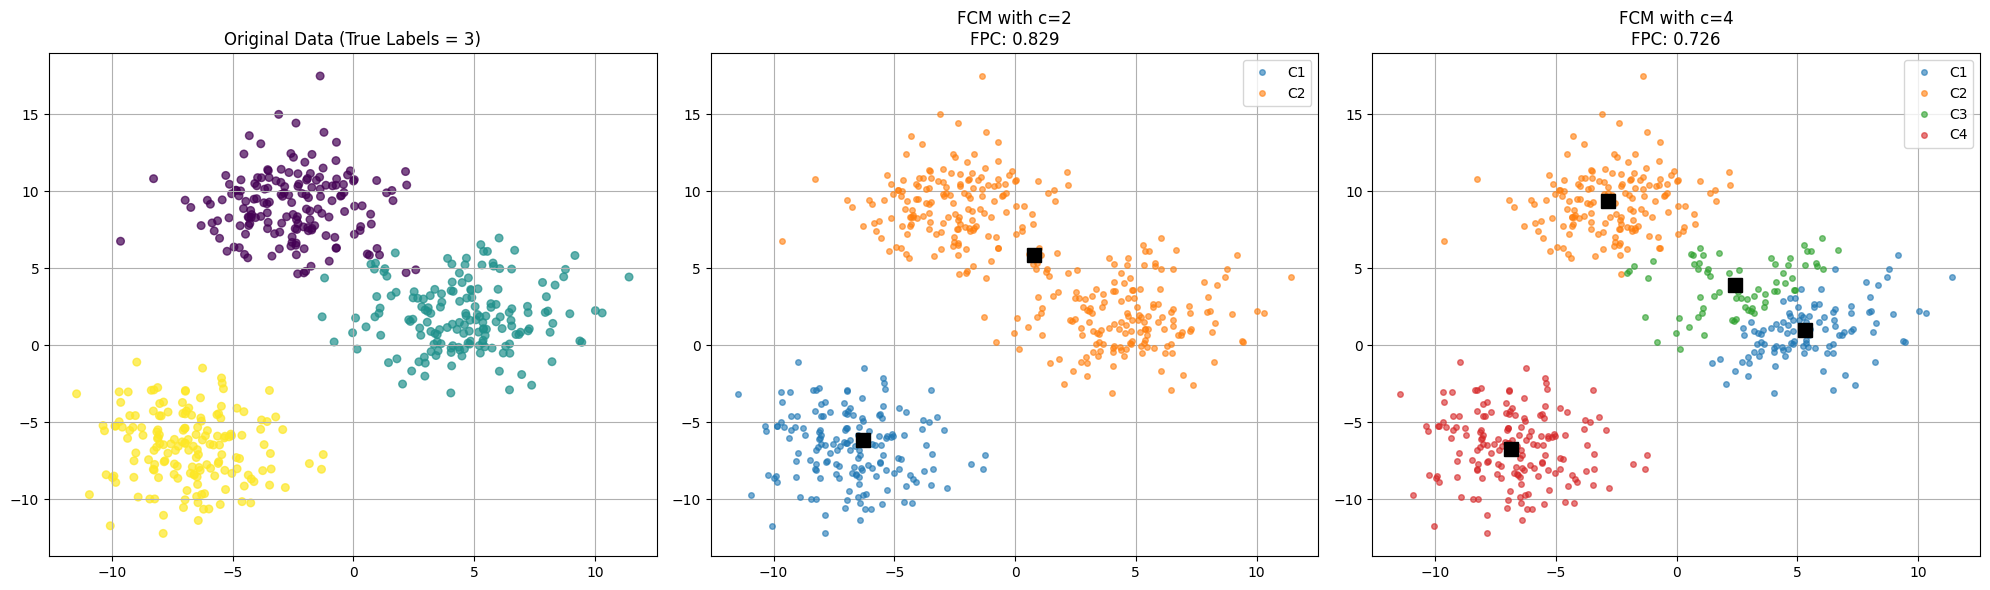

In [18]:
def run_and_plot_fcm(data_t, num_clusters, fuzziness, ax, title):
    cntr_fcm, u_fcm, _, _, _, _, fpc_fcm = fuzz.cluster.cmeans(
        data_t, c=num_clusters, m=fuzziness, error=0.005, maxiter=1000, seed=fcm_seed)
    
    cluster_membership_fcm = np.argmax(u_fcm, axis=0)
    
    for j in range(num_clusters):
        ax.plot(data_t[0, cluster_membership_fcm == j],
                data_t[1, cluster_membership_fcm == j], '.', 
                markersize=8, alpha=0.6, label=f'C{j+1}')
    for pt in cntr_fcm:
        ax.plot(pt[0], pt[1], 'ks', markersize=10)
    
    ax.set_title(f'{title}\nFPC: {fpc_fcm:.3f}')
    ax.grid(True)
    ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Original data plot for reference
axes[0].scatter(data[0, :], data[1, :], c=true_labels, s=30, cmap='viridis', alpha=0.7)
axes[0].set_title('Original Data (True Labels = 3)')
axes[0].grid(True)

# FCM with c=2
run_and_plot_fcm(data, num_clusters=2, fuzziness=m_fuzziness, ax=axes[1], title='FCM with c=2')

# FCM with c=4
run_and_plot_fcm(data, num_clusters=4, fuzziness=m_fuzziness, ax=axes[2], title='FCM with c=4')

plt.tight_layout()
plt.show()

### 4.2. Fuzziness Coefficient (`m`)

The fuzziness coefficient `m` (where `m > 1`) controls the degree of fuzziness of the clusters.
* As `m` approaches 1, the clustering becomes harder (closer to K-Means).
* As `m` increases, the clusters become fuzzier, and memberships `u_ij` tend to spread more evenly (approaching `1/c`).

Typical values for `m` are between 1.5 and 3.0. The default in many implementations is `m=2.0`.

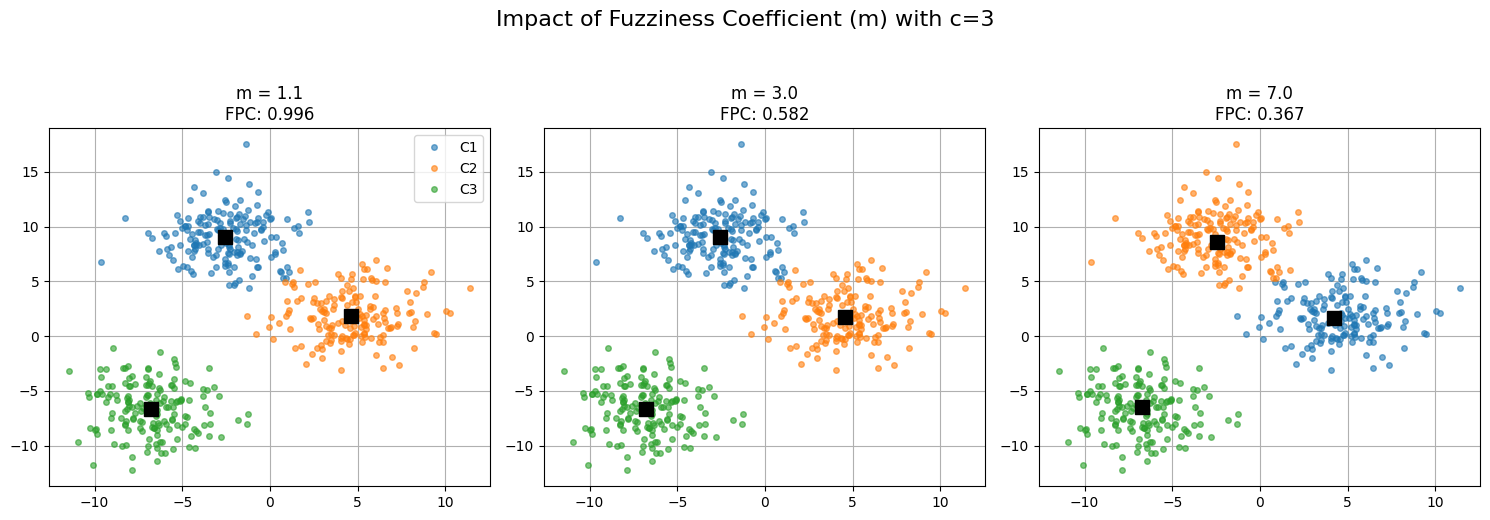

In [21]:
m_values = [1.1, 3.0, 7.0] # Different fuzziness values to test
num_clusters_for_m_test = 3

fig, axes = plt.subplots(1, len(m_values), figsize=(15, 5))
fig.suptitle(f'Impact of Fuzziness Coefficient (m) with c={num_clusters_for_m_test}', fontsize=16, y=1.03)

for i, m_val in enumerate(m_values):
    cntr_m, u_m, _, _, _, _, fpc_m = fuzz.cluster.cmeans(
        data, c=num_clusters_for_m_test, m=m_val, error=0.005, maxiter=1000, seed=fcm_seed)
    
    cluster_membership_m = np.argmax(u_m, axis=0)
    
    ax = axes[i]
    for j in range(num_clusters_for_m_test):
        ax.plot(data[0, cluster_membership_m == j],
                data[1, cluster_membership_m == j], '.', 
                markersize=8, alpha=0.6, label=f'C{j+1}')
    for pt in cntr_m:
        ax.plot(pt[0], pt[1], 'ks', markersize=10)
    
    ax.set_title(f'm = {m_val:.1f}\nFPC: {fpc_m:.3f}')
    ax.grid(True)
    if i == 0: ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Observe how for very low `m` (e.g., 1.1), the clusters are very crisp. As `m` increases, the boundaries become less distinct in terms of membership values (though the max membership plot might still look somewhat crisp). Very high `m` values can lead to overly fuzzy clusters where points have almost equal membership to all centers.

## 5. Predicting Memberships for New Data (`cmeans_predict`)

Once you have trained an FCM model (i.e., you have the final cluster centers `cntr` and the fuzziness coefficient `m`), you can predict the fuzzy memberships for **new, unseen data points** using `skfuzzy.cluster.cmeans_predict`.

**Inputs to `cmeans_predict`:**
* `test_data`: New data points for which to predict memberships. Shape `(D, N_test)` where `D` is features, `N_test` is number of new points.
* `cntr_trained`: The cluster centers obtained from training FCM on the original data. Shape `(c, D)`.
* `m`: The fuzziness coefficient used during training.
* `error`, `maxiter`: Similar to `cmeans`, for the membership calculation iterative process (though often it's a direct calculation).

**Outputs of `cmeans_predict`:**
* `u_new`: The fuzzy membership matrix for the new data. Shape `(c, N_test)`.
* `u0_new`, `d_new`, `jm_new`, `p_new`, `fpc_new`: Similar to `cmeans` outputs, but for the prediction on new data.

New data points:
[[  1.91441304  -8.8581325  -12.23022712   4.61353598  -2.2162584
   -1.41271816  -5.72653218  -8.86442954   2.2813264   11.52344147]
 [ -0.35364986  -0.6332949   -3.70439735  11.75910603   3.23124779
    3.20057901   3.63371791  -8.84618304   0.4553976    8.72846391]]

Predicted memberships for new data (columns are points, rows are clusters):
[[0.092 0.199 0.117 0.582 0.505 0.454 0.58  0.024 0.068 0.29 ]
 [0.821 0.141 0.095 0.345 0.349 0.416 0.205 0.029 0.882 0.609]
 [0.087 0.66  0.788 0.073 0.147 0.13  0.215 0.947 0.05  0.101]]

Cluster assignments for new data (max membership):
[1 2 2 0 0 0 0 2 1 1]


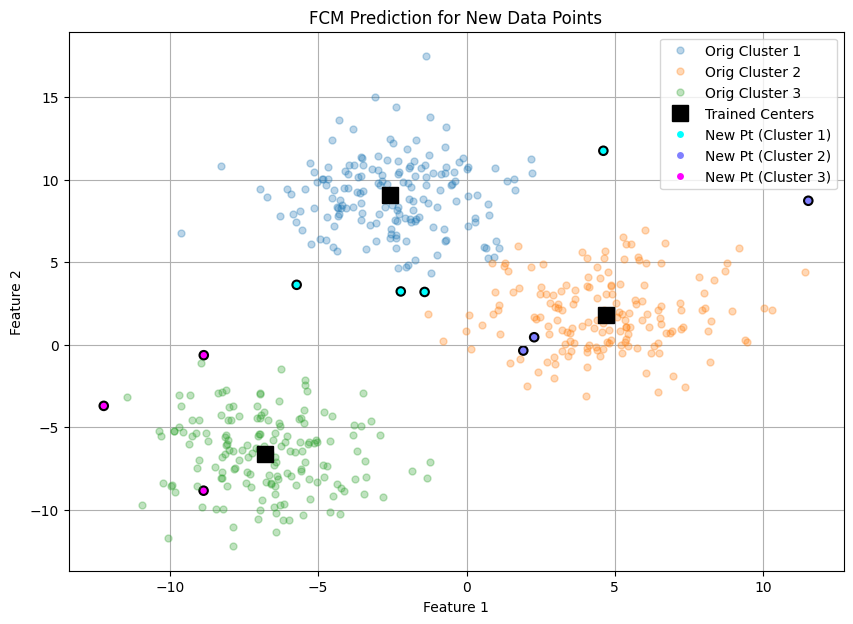

In [ ]:
# Generate some new data points for prediction
n_new_samples = 10
new_data, _ = make_blobs(n_samples=n_new_samples, 
                           cluster_std=3, 
                           random_state=101)
new_data = new_data.T

# Predict memberships for the new data
u_new, u0_new, d_new, jm_new, p_new, fpc_new = fuzz.cluster.cmeans_predict(
    new_data, 
    cntr_trained=cntr, # Use the centers from the original FCM run
    m=m_fuzziness, 
    error=error_tolerance, 
    maxiter=max_iterations,
    seed=fcm_seed)

print("New data points:")
print(new_data)
print("\nPredicted memberships for new data (columns are points, rows are clusters):")
print(np.round(u_new, 3))

# Assign new points to clusters based on max membership
new_data_cluster_assignment = np.argmax(u_new, axis=0)
print("\nCluster assignments for new data (max membership):")
print(new_data_cluster_assignment)

# Visualize original data, FCM centers, and new predicted points
plt.figure(figsize=(10, 7))
cluster_membership_original = np.argmax(u, axis=0)
for j in range(n_clusters_fcm):
    plt.plot(data[0, cluster_membership_original == j],
             data[1, cluster_membership_original == j], '.', 
             label=f'Orig Cluster {j+1}', markersize=10, alpha=0.3)
for pt_idx, pt in enumerate(cntr):
    plt.plot(pt[0], pt[1], 'ks', markersize=12, label='Trained Centers' if pt_idx == 0 else None)

# Plot new data points colored by their predicted cluster
scatter_new = plt.scatter(new_data[0, :], new_data[1, :], 
                          c=new_data_cluster_assignment, s=150, cmap='cool', 
                          edgecolors='black', linewidth=1.5, marker='.')

# Create a legend for new data points
handles, labels = plt.gca().get_legend_handles_labels()
from matplotlib.lines import Line2D
legend_elements_new = [Line2D([0], [0], marker='.', color='w', label=f'New Pt (Cluster {i+1})', 
                           markerfacecolor=plt.cm.cool(i / (n_clusters_fcm -1 if n_clusters_fcm >1 else 1)), 
                           markersize=12) for i in range(n_clusters_fcm)]
plt.legend(handles=handles + legend_elements_new)

plt.title('FCM Prediction for New Data Points')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()